# Signal deep-dive

A post-selection EDA on the ~405 survivors: which feature *families* carry the signal, what the top features' relationships to default actually look like, and what clusters together. The goal is intuition for the next round of feature engineering.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from src.data import load_selected

X, y = load_selected()
model = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                           n_jobs=-1, verbose=-1).fit(X, y)
imp = pd.Series(model.booster_.feature_importance("gain"), index=X.columns)

def family(c):
    cl = c.lower()
    if "ext_source" in cl or cl.startswith("ext_calc_"): return "external (bought)"
    if cl.startswith(("x_pca_", "x_kmeans_", "x_ae_")):   return "learned (pca/kmeans/ae)"
    if cl.startswith("x_"):                                return "cross-table"
    if cl.startswith(("bureau", "bb_")):                   return "bureau"
    if cl.startswith("prev"):                              return "previous_app"
    if cl.startswith("pos"):                               return "pos_cash"
    if cl.startswith("ins"):                               return "installments"
    if cl.startswith("cc"):                                return "credit_card"
    ratios = ("credit_to", "payment_rate", "annuity_income", "income_per", "credit_per",
              "children_ratio", "days_employed", "car_to", "phone_to", "child_to", "cnt_non")
    if any(r in cl for r in ratios):                       return "application ratios"
    return "application raw"
X.shape

(307511, 441)

## Where the signal lives — by family

How many features each family kept, and how much of the total model gain they carry. The gain share is the real answer to "what type of relationship has the most signal."

In [2]:
fam = X.columns.to_series().map(family)
tbl = pd.DataFrame({
    "n_features": fam.value_counts(),
    "total_gain": imp.groupby(fam).sum().round(0),
    "gain_share": (imp.groupby(fam).sum() / imp.sum()).round(3),
}).sort_values("gain_share", ascending=False)
print(tbl.to_string())

                         n_features  total_gain  gain_share
external (bought)                14    224838.0       0.361
bureau                          116     65728.0       0.106
application raw                  44     62283.0       0.100
previous_app                     78     56286.0       0.090
cross-table                      63     53357.0       0.086
installments                     33     49223.0       0.079
application ratios               11     37232.0       0.060
learned (pca/kmeans/ae)          15     28603.0       0.046
credit_card                      38     25249.0       0.041
pos_cash                         29     20199.0       0.032


## Top individual features

In [3]:
imp.sort_values(ascending=False).head(25).round(0)

ext_calc_mean                           129798.0
ext_calc_median                          28215.0
ext_calc_max                             15832.0
ext_calc_2x3                             12134.0
ext_calc_min                             11273.0
x_pca_7                                  10002.0
DAYS_BIRTH                                7967.0
credit_to_annuity                         7918.0
DAYS_EMPLOYED                             7458.0
bureau_debt_credit                        7444.0
EXT_SOURCE_3                              7428.0
prev_DAYS_LAST_DUE_1ST_VERSION_max        7400.0
ext_calc_1_to_birth                       7351.0
cc_util_max_6                             7112.0
ins_last_loan_late_share                  5934.0
payment_rate                              5464.0
credit_to_goods                           5447.0
ins_late_max_730                          5333.0
bureau_active_DAYS_CREDIT_max             4618.0
days_employed_percentage                  4432.0
annuity_to_goods    

## Relationship shapes — top features vs default

Default rate across deciles of each top feature. Monotonic, U-shaped, or a threshold each hints at a different kind of feature worth building more of.

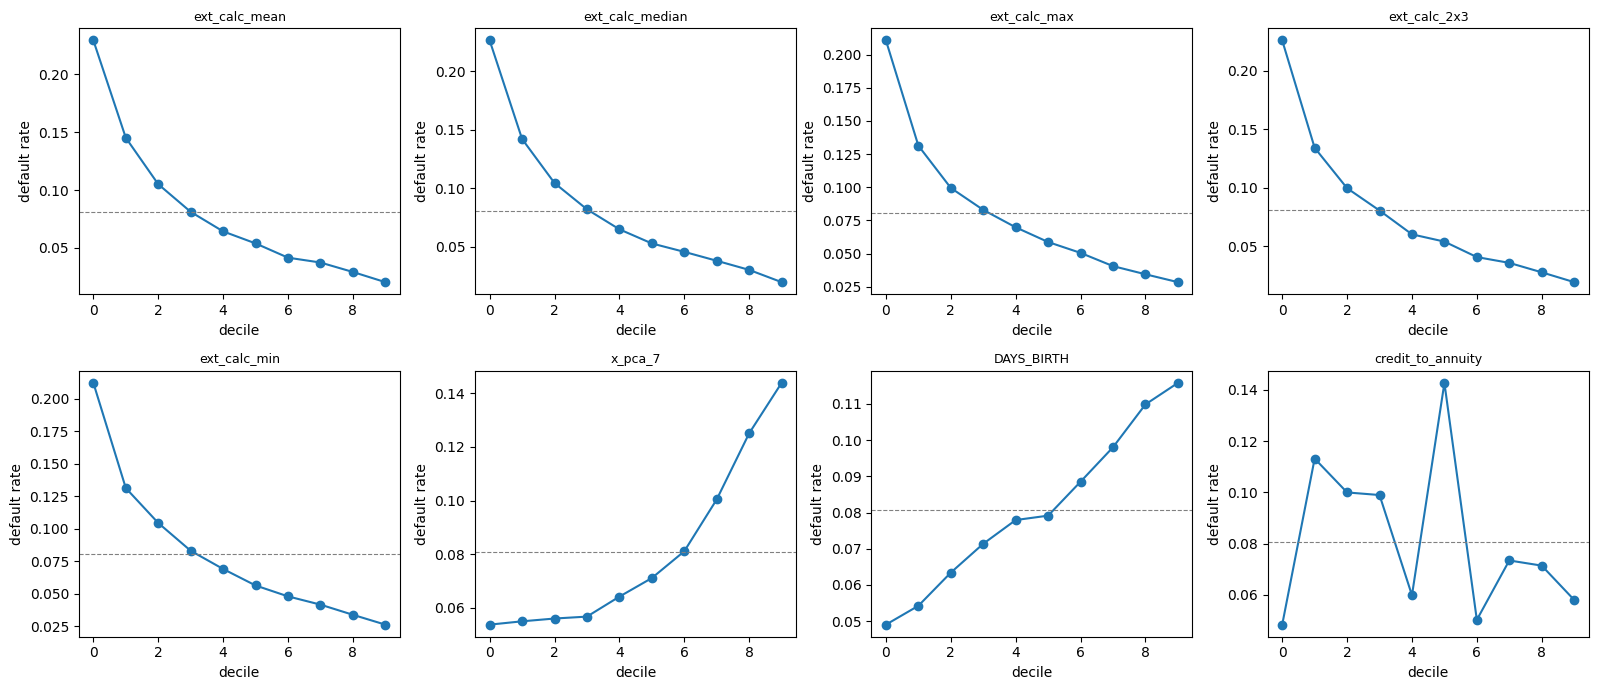

In [4]:
top = imp.sort_values(ascending=False).head(8).index
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), top):
    d = pd.qcut(X[c], 10, labels=False, duplicates="drop")
    rate = y.groupby(d).mean()
    ax.plot(rate.index, rate.values, marker="o")
    ax.axhline(y.mean(), color="gray", ls="--", lw=0.8)
    ax.set_title(c, fontsize=9); ax.set_xlabel("decile"); ax.set_ylabel("default rate")
plt.tight_layout(); plt.show()

## What clusters together

Correlation among the top features. Tight blocks are themes you already cover well; isolated features are unique angles.

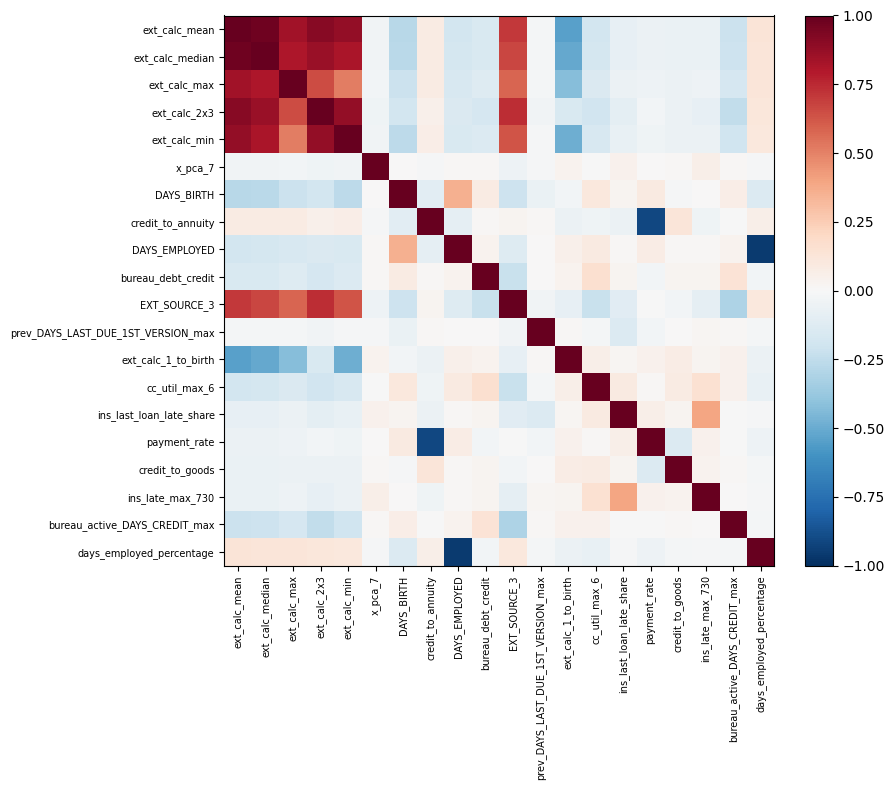

In [5]:
top20 = imp.sort_values(ascending=False).head(20).index
corr = X[top20].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(top20))); ax.set_xticklabels(top20, rotation=90, fontsize=7)
ax.set_yticks(range(len(top20))); ax.set_yticklabels(top20, fontsize=7)
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## Iteration 4 ideas

_Fill in after reading the output above — e.g. if `application ratios` and `installments` dominate the gain share, build more affordability ratios and payment-timing features; if a top feature's default curve is a sharp threshold, add a flag at that break; if the top features are all correlated, the gaps are the untouched angles._